In [ ]:
 !pip install numba

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from numba import njit
from pylab import imshow, show
from timeit import default_timer as timer

Mandelbrot created in 1.1347 seconds


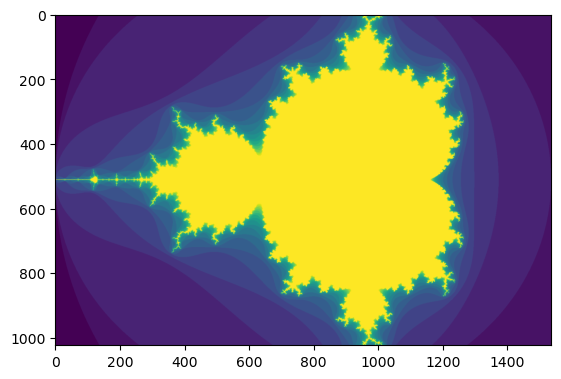

In [2]:
# njit (No-Python mode) is the fastest way to run code on the CPU
@njit
def mandel(x, y, max_iters):
    c = complex(x, y)
    z = 0.0j
    for i in range(max_iters):
        z = z*z + c
        if (z.real*z.real + z.imag*z.imag) >= 4.0:
            return i
    return max_iters

@njit
def create_fractal(min_x, max_x, min_y, max_y, image, iters):
    height = image.shape[0]
    width = image.shape[1]

    pixel_size_x = (max_x - min_x) / width
    pixel_size_y = (max_y - min_y) / height

    # Loops are usually slow in Python, but njit makes them blazing fast
    for x in range(width):
        real = min_x + x * pixel_size_x
        for y in range(height):
            imag = min_y + y * pixel_size_y
            color = mandel(real, imag, iters)
            image[y, x] = color # Fixed parenthesis to brackets

# Setup the canvas
image = np.zeros((1024, 1536), dtype=np.uint8)

# Run and time it
start = timer()
create_fractal(-2.0, 1.0, -1.0, 1.0, image, 20)
dt = timer() - start

print(f"Mandelbrot created in {dt:.4f} seconds")

# Display the result
imshow(image)
show()


Mandelbrot created in 3.3727 seconds


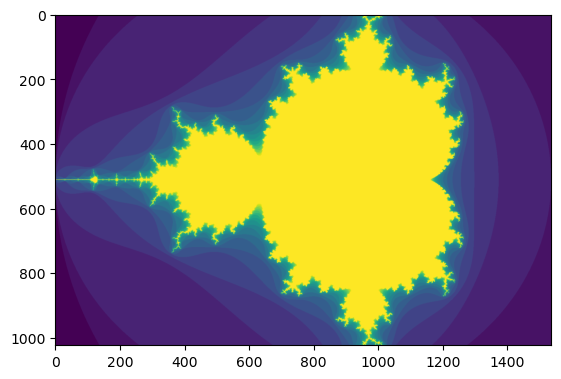

In [3]:
# njit (No-Python mode) is the fastest way to run code on the CPU

def mandel(x, y, max_iters):
    c = complex(x, y)
    z = 0.0j
    for i in range(max_iters):
        z = z*z + c
        if (z.real*z.real + z.imag*z.imag) >= 4.0:
            return i
    return max_iters

def create_fractal(min_x, max_x, min_y, max_y, image, iters):
    height = image.shape[0]
    width = image.shape[1]

    pixel_size_x = (max_x - min_x) / width
    pixel_size_y = (max_y - min_y) / height

    # Loops are usually slow in Python, but njit makes them blazing fast
    for x in range(width):
        real = min_x + x * pixel_size_x
        for y in range(height):
            imag = min_y + y * pixel_size_y
            color = mandel(real, imag, iters)
            image[y, x] = color # Fixed parenthesis to brackets

# Setup the canvas
image = np.zeros((1024, 1536), dtype=np.uint8)

# Run and time it
start = timer()
create_fractal(-2.0, 1.0, -1.0, 1.0, image, 20)
dt = timer() - start

print(f"Mandelbrot created in {dt:.4f} seconds")

# Display the result
imshow(image)
show()
